In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
import os
print(os.getcwd())

c:\Bluestock Fintech\Mutual_fund_analytics\notebooks


In [4]:
df = pd.read_csv("../data/processed/clean_nav.csv")

In [5]:
print(type(df))

<class 'pandas.DataFrame'>


In [6]:
print(df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [7]:
print(df.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [8]:
df["date"] = pd.to_datetime(df["date"])

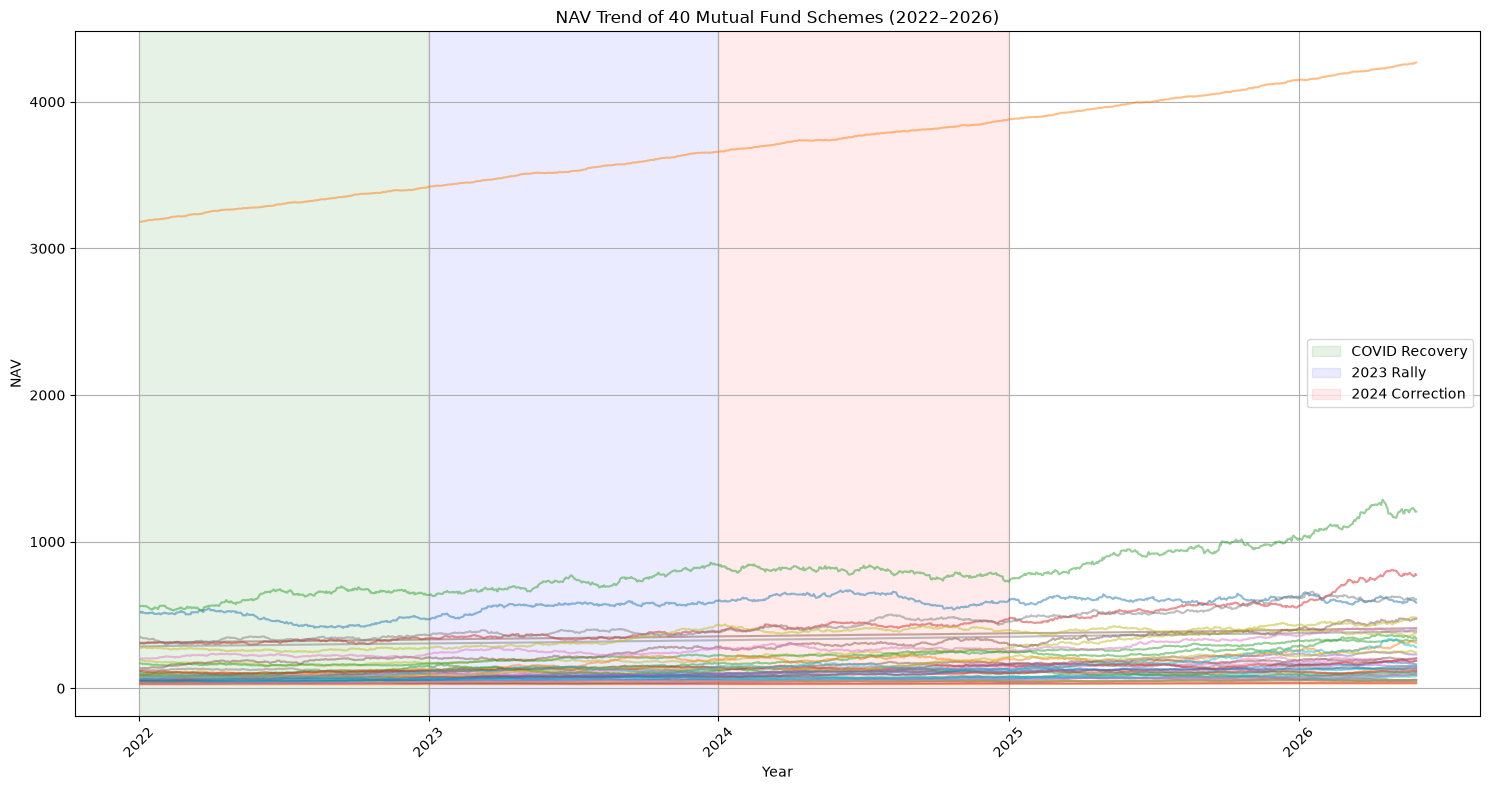

In [9]:
plt.figure(figsize=(15,8))

for code in df["amfi_code"].unique():
    temp = df[df["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], alpha=0.5)

plt.title("NAV Trend of 40 Mutual Fund Schemes (2022–2026)")
plt.xlabel("Year")
plt.ylabel("NAV")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)

# COVID recovery
plt.axvspan(pd.Timestamp("2022-01-01"),
            pd.Timestamp("2022-12-31"),
            color="green",
            alpha=0.1,
            label="COVID Recovery")

# 2023 rally
plt.axvspan(pd.Timestamp("2023-01-01"),
            pd.Timestamp("2023-12-31"),
            color="blue",
            alpha=0.08,
            label="2023 Rally")

# 2024 correction
plt.axvspan(pd.Timestamp("2024-01-01"),
            pd.Timestamp("2024-12-31"),
            color="red",
            alpha=0.08,
            label="2024 Correction")

plt.legend()
plt.tight_layout()
plt.show()

In [10]:
plt.savefig("../reports/nav_trend_2022_2026.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Findings

- Daily NAV data for all 40 schemes from 2022–2026 was visualized.
- Most schemes show a steady long-term increase in NAV.
- The market recovered well during 2022 after the COVID period.
- Strong upward momentum was observed during 2023.
- Some schemes showed temporary corrections during 2024 before recovering.
- Overall, the long-term trend indicates positive growth across most mutual fund schemes.

TASK - 2  

In [11]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [12]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [13]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [14]:
print(aum.dtypes)

date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object


In [15]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [16]:
aum.isnull().sum()

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [17]:
aum["date"] = pd.to_datetime(aum["date"])

In [18]:
aum["year"] = aum["date"].dt.year

In [19]:
print(aum["year"].unique())

[2022 2023 2024 2025]


In [20]:
pivot = aum.pivot_table(
    index = "fund_house",
    columns = "year",
    values = "aum_crore",
    aggfunc = "mean"
)

pivot

year,2022,2023,2024,2025
fund_house,,,,
Aditya Birla Sun Life MF,281500.0,291500.0,3.620000e+05,422500.0
Axis Mutual Fund,245000.0,250500.0,2.900000e+05,330000.0
DSP Mutual Fund,111000.0,123500.0,1.716667e+05,212500.0
HDFC Mutual Fund,440000.0,492500.0,7.140000e+05,862500.0
ICICI Prudential MF,476500.0,545000.0,7.653333e+05,977000.0
Kotak Mahindra MF,271000.0,307000.0,4.246667e+05,536000.0
Mirae Asset MF,106500.0,129000.0,1.916667e+05,257500.0
Nippon India MF,274000.0,316500.0,4.893333e+05,630000.0
SBI Mutual Fund,617500.0,781000.0,1.064667e+06,1250000.0


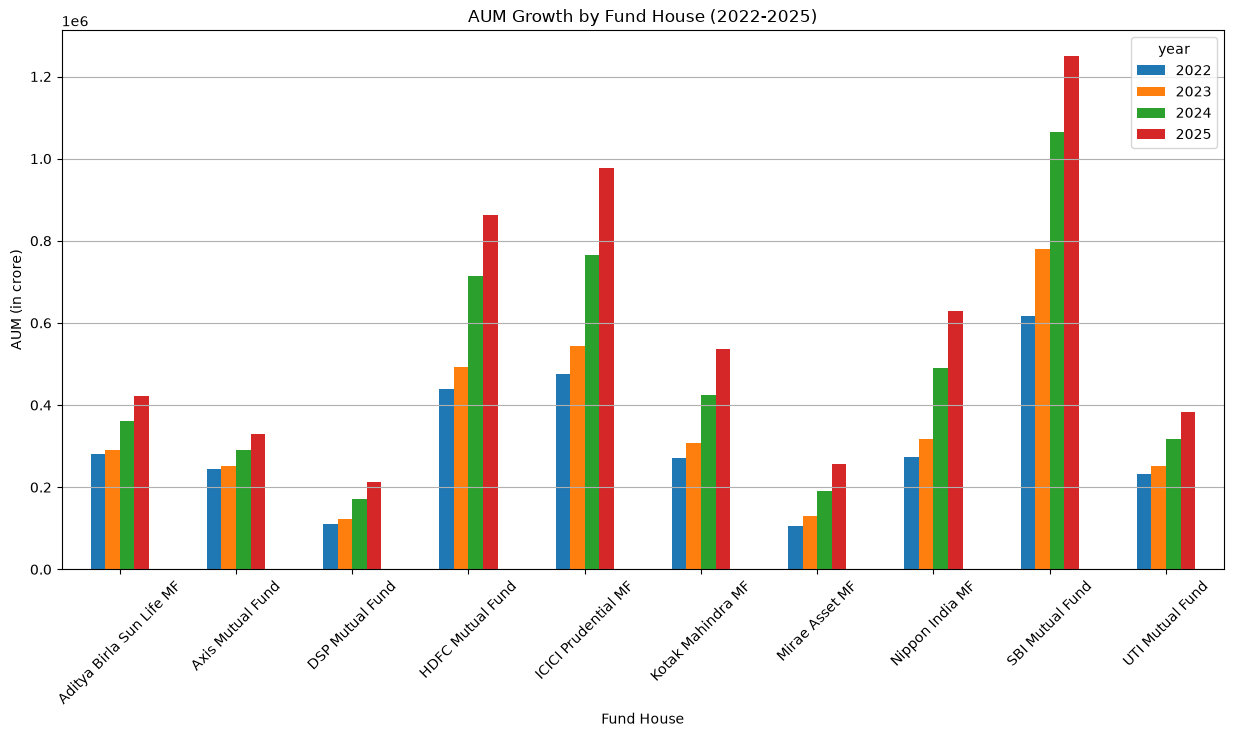

In [21]:
ax = pivot.plot(
    kind = "bar",
    figsize = (15,7)
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (in crore)")
plt.xticks(rotation = 45)
plt.grid(axis="y")


plt.show()

In [22]:
top_amc = (
    aum.groupby("fund_house")["aum_crore"]
    .max()
    .sort_values(ascending=False)
)

print(top_amc.head(10))

fund_house
SBI Mutual Fund             1250000
ICICI Prudential MF         1074000
HDFC Mutual Fund             930000
Nippon India MF              700000
Kotak Mahindra MF            580000
Aditya Birla Sun Life MF     460000
UTI Mutual Fund              410000
Axis Mutual Fund             350000
Mirae Asset MF               290000
DSP Mutual Fund              230000
Name: aum_crore, dtype: int64


In [23]:
print(top_amc.head())

fund_house
SBI Mutual Fund        1250000
ICICI Prudential MF    1074000
HDFC Mutual Fund        930000
Nippon India MF         700000
Kotak Mahindra MF       580000
Name: aum_crore, dtype: int64


 Findings

- Compared AUM across all fund houses from 2022 to 2025.
- Most AMCs showed steady growth in assets under management.
- SBI Mutual Fund maintained one of the highest AUMs.
- HDFC Mutual Fund and ICICI Prudential Mutual Fund also managed high AUM values.
- Overall industry AUM increased during the study period.

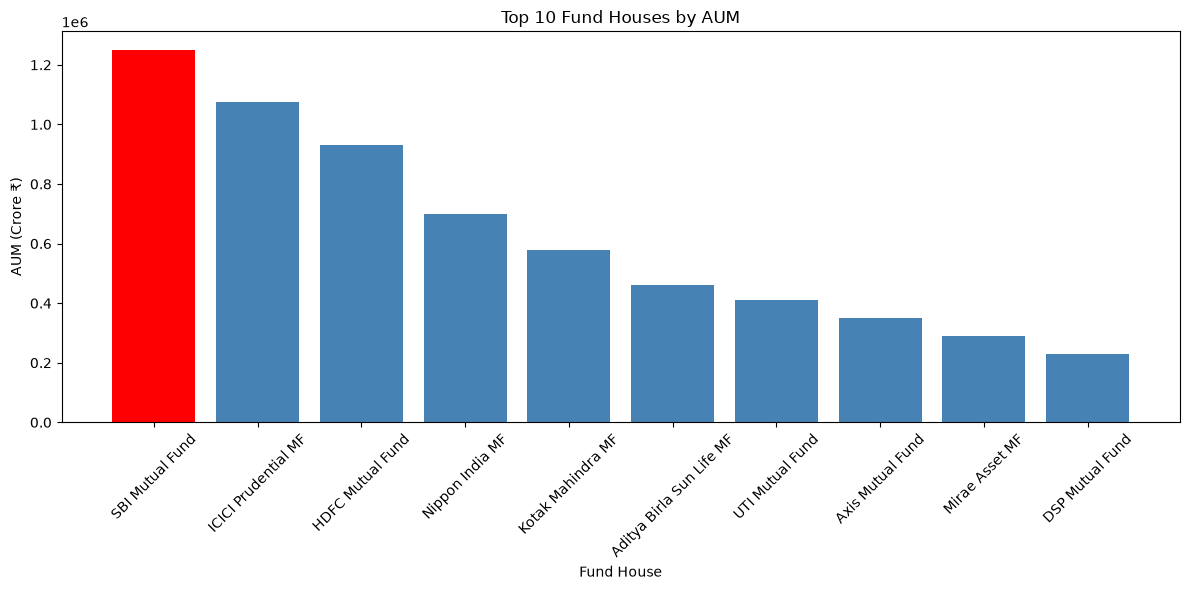

In [24]:

colors = []

for fund in top_amc.index:
    if fund == "SBI Mutual Fund":
        colors.append("red")
    else:
        colors.append("steelblue")

plt.figure(figsize=(12,6))

plt.bar(top_amc.index, top_amc.values, color=colors)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore ₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Findings

SBI Mutual Fund ranks first among the top 10 fund houses with the highest AUM.
ICICI Prudential MF and HDFC Mutual Fund are the closest competitors but still trail SBI by a considerable margin.
The distribution of AUM is not uniform; a few large AMCs manage a significant share of the industry's total assets.

## Task - 3

SIP inflow time-series: Monthly SIP
inflow Jan 2022 to Dec 2025. Mark
the Rs.31,002 Cr milestone (Dec
2025).

In [25]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

In [26]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [27]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [28]:
sip.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [29]:
sip.shape

(48, 6)

In [30]:
sip.dtypes

month                            str
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

In [31]:
sip["month"] = pd.to_datetime(sip["month"])

In [32]:
sip.dtypes

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object

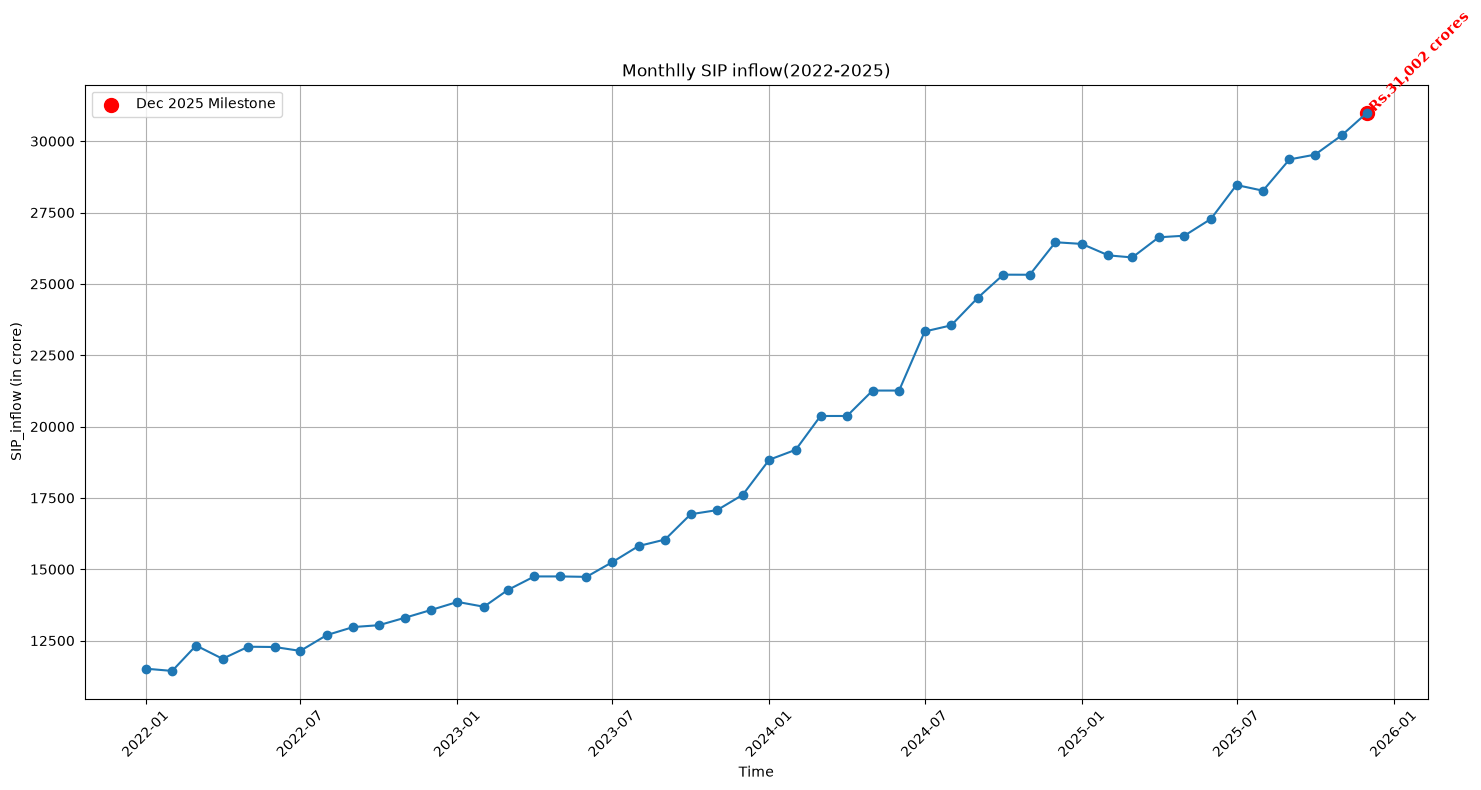

In [33]:
plt.figure(
    figsize = (15,8)
)
plt.plot(sip["month"], sip["sip_inflow_crore"],marker = "o")

plt.scatter(
    sip.iloc[-1]["month"],
    sip.iloc[-1]["sip_inflow_crore"],
    color = "red",
    s = 100,
    label = "Dec 2025 Milestone"
)

plt.text(
    sip.iloc[-1]["month"],
    sip.iloc[-1]["sip_inflow_crore"] + 50,
    "Rs.31,002 crores",rotation = 45, color="red", fontweight="bold"
)

plt.legend()

plt.title("Monthlly SIP inflow(2022-2025)")
plt.ylabel("SIP_inflow (in crore)")
plt.xlabel("Time")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid(True)
plt.show()

## Task 3 Findings

- Monthly SIP inflows show a steady upward trend from 2022 to 2025.
- SIP investments increased consistently, indicating growing retail investor participation.
- December 2025 recorded the highest SIP inflow of approximately ₹31,002 crore.
- The continuous rise in SIP inflows reflects increasing investor confidence and long-term investment discipline.
- The overall trend highlights the expanding popularity of Systematic Investment Plans in the Indian mutual fund industry.

## Task 4 
Category-wise inflow heatmap:
Months on X-axis, categories on
Y-axis, net inflow as colour intensity.


In [34]:
import seaborn as sns

In [35]:
cat = pd.read_csv("../data/raw/05_category_inflows.csv")

In [36]:
cat.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [37]:
cat.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [38]:
cat.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [39]:
cat.dtypes

month                   str
category                str
net_inflow_crore    float64
dtype: object

In [40]:
cat["month"] = pd.to_datetime(cat["month"])
cat["month"] = cat["month"].dt.strftime("%Y-%m")

In [41]:
pivot = cat.pivot(
    index = "category",
    columns = "month",
    values = "net_inflow_crore"
)

pivot.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


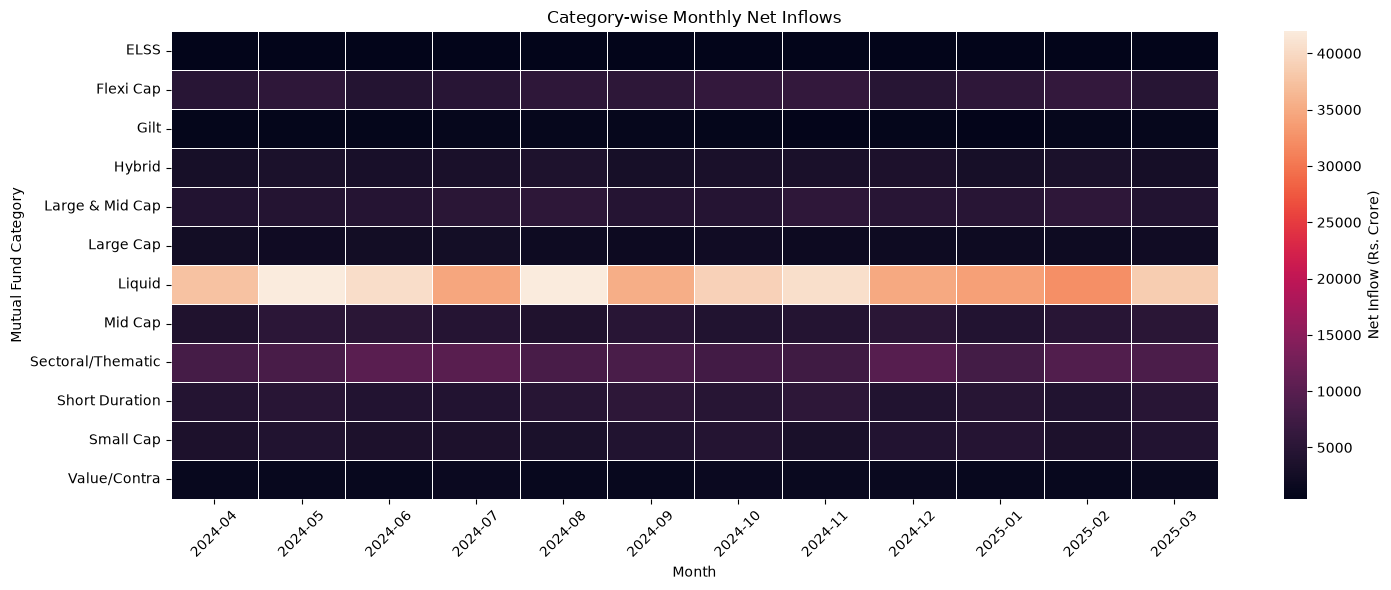

In [42]:
plt.figure(figsize = (15,6))

sns.heatmap(
    pivot, linewidth = 0.5, linecolor = "white",
    cbar_kws = {"label":"Net Inflow (Rs. Crore)"} 
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Mutual Fund Category")

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

##Key Findings:

-Liquid Funds consistently recorded the highest net inflows throughout the period (Apr 2024 – Mar 2025), indicating strong investor preference for low-risk and liquid investment options.

-Sectoral/Thematic Funds attracted moderate inflows, showing investors' interest in sector-specific investment opportunities.

-Flexi Cap, Large & Mid Cap, Mid Cap, and Small Cap funds maintained steady inflows with only minor month-to-month fluctuations.

-ELSS, Gilt, and Value/Contra Funds received comparatively lower inflows during most months.

-The heatmap clearly shows that investor preferences remained relatively stable over the year, with Liquid Funds dominating the inflow landscape.

## Task 5 
Investor demographics: Age group
distribution pie chart. SIP amount box
plot by age group.

In [43]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

In [44]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [45]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [46]:
investor.dtypes

investor_id               str
transaction_date          str
amfi_code               int64
transaction_type          str
amount_inr              int64
state                     str
city                      str
city_tier                 str
age_group                 str
gender                    str
annual_income_lakh    float64
payment_mode              str
kyc_status                str
dtype: object

In [47]:
investor.isnull().sum()

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [48]:
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

In [49]:
investor.dtypes

investor_id                      str
transaction_date      datetime64[us]
amfi_code                      int64
transaction_type                 str
amount_inr                     int64
state                            str
city                             str
city_tier                        str
age_group                        str
gender                           str
annual_income_lakh           float64
payment_mode                     str
kyc_status                       str
dtype: object

In [50]:
age_counts = investor["age_group"].value_counts()

In [51]:
age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [52]:
plt.figure(figsize = (7,7))

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

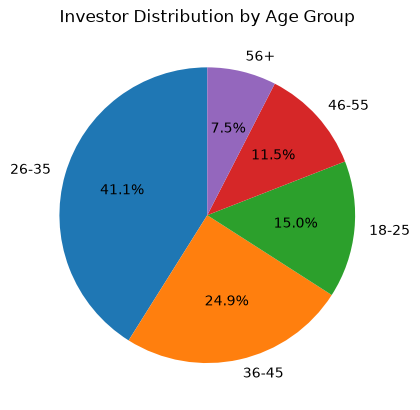

In [53]:
plt.pie(
    age_counts,
    labels = age_counts.index,
    autopct="%1.1f%%",
    startangle = 90
)

plt.title("Investor Distribution by Age Group")

plt.show()

Findings:

1.The 26–35 age group represents the largest share of investors (41.1%), indicating that young professionals are the most active participants in mutual fund investments.

2.The 36–45 age group is the second-largest segment (24.9%), showing continued investment interest among mid-career individuals.

3.The 18–25 age group contributes 15.0%, suggesting that younger investors are entering the mutual fund market but still form a smaller proportion.

4.The 46–55 age group accounts for 11.5% of investors.

5.Investors aged 56+ make up the smallest segment (7.5%), indicating comparatively lower participation.

In [54]:
sip = investor[investor["transaction_type"] == "SIP"]

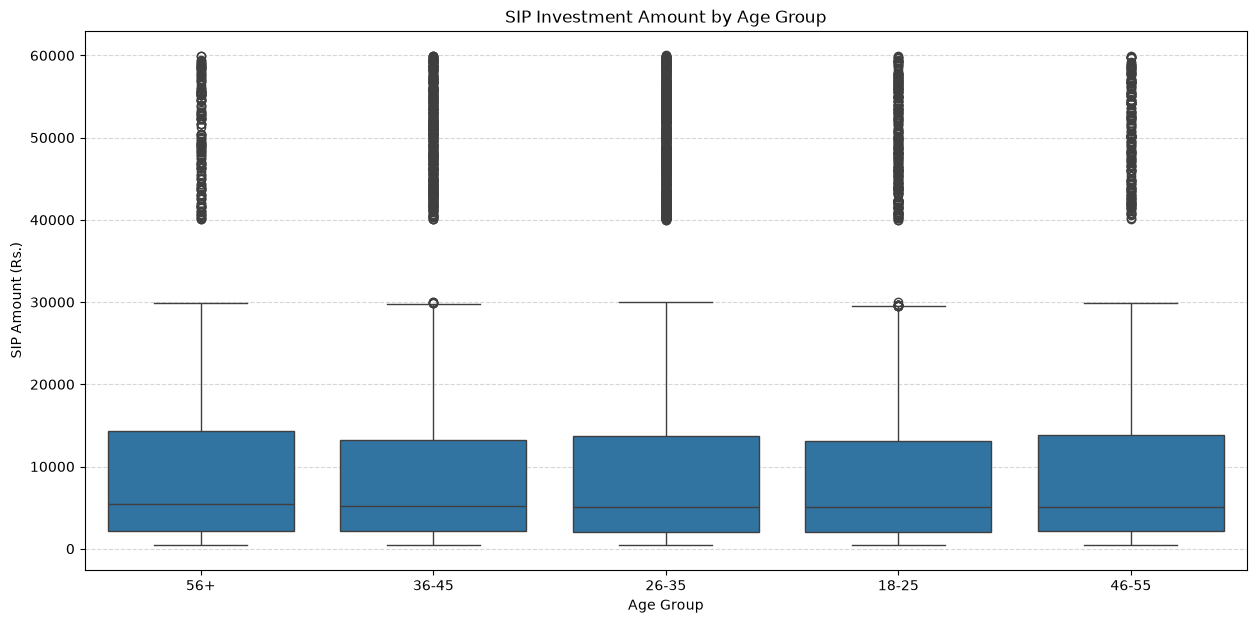

In [55]:


plt.figure(figsize = (15,7))

sns.boxplot(
    data = sip, x = "age_group", y = "amount_inr"
)

plt.title("SIP Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (Rs.)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Findings

1.The median SIP investment amount is fairly similar across all age groups, suggesting that investors of different ages tend to invest comparable monthly SIP amounts.

2.All age groups show a wide spread of investment amounts, indicating considerable variation in SIP contributions.

3.Numerous high-value outliers (₹40,000–₹60,000) are present across every age group, indicating that some investors contribute significantly higher SIP amounts than the majority.

4.No single age group clearly dominates in terms of SIP investment size, implying that investment behavior is relatively consistent across age groups.

## Task 6 
Geographic distribution: Horizontal
bar chart — SIP amount by state. T30
vs B30 pie chart.

In [56]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [57]:
investor["state"].value_counts

<bound method IndexOpsMixin.value_counts of 0             Telangana
1                Punjab
2               Haryana
3           Maharashtra
4                 Delhi
              ...      
32773    Madhya Pradesh
32774     Uttar Pradesh
32775         Rajasthan
32776       West Bengal
32777         Telangana
Name: state, Length: 32778, dtype: str>

In [ ]:

sip = investor[
investor["transaction_type"].str.strip().str.lower() == "sip"
]

In [60]:
state_sip = (
    sip.groupby("state")["amount_inr"].sum().sort_values(ascending = False)
)

state_sip

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Rajasthan         16544233
Maharashtra       16445629
Name: amount_inr, dtype: int64

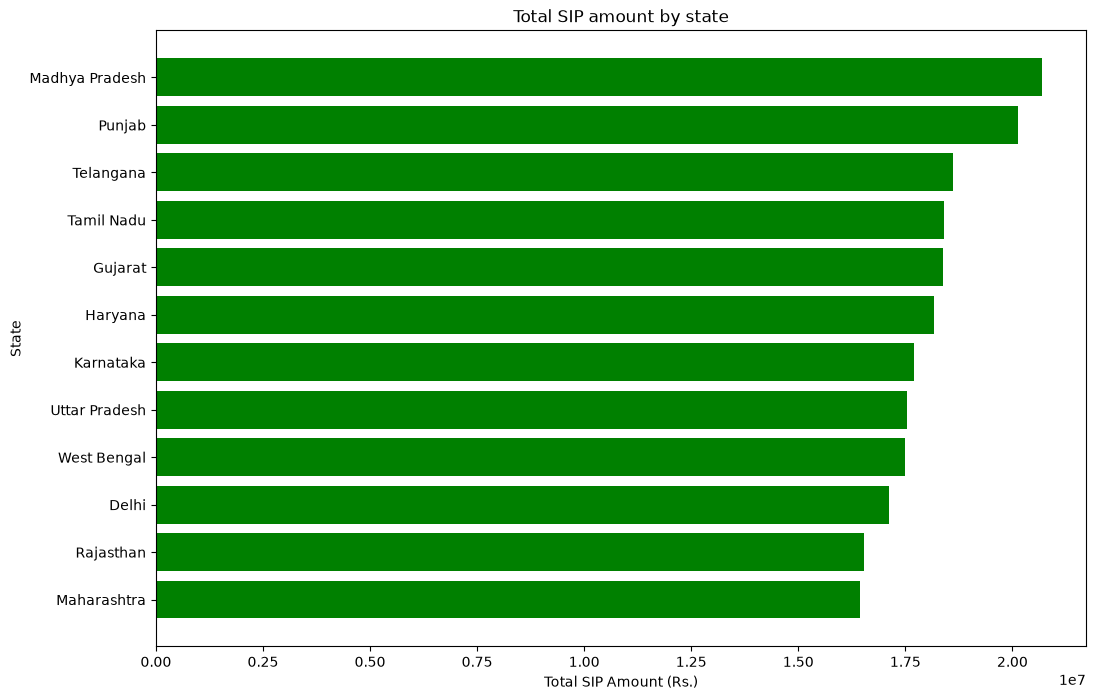

In [77]:
plt.figure(figsize = (12,8))

plt.barh(
    state_sip.index,
    state_sip.values,
    color = "green"
)

plt.title("Total SIP amount by state")
plt.xlabel("Total SIP Amount (Rs.)")
plt.ylabel("State")

plt.gca().invert_yaxis() # bring highest value on top

plt.show()

In [78]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [82]:
tier = investor["city_tier"].value_counts()

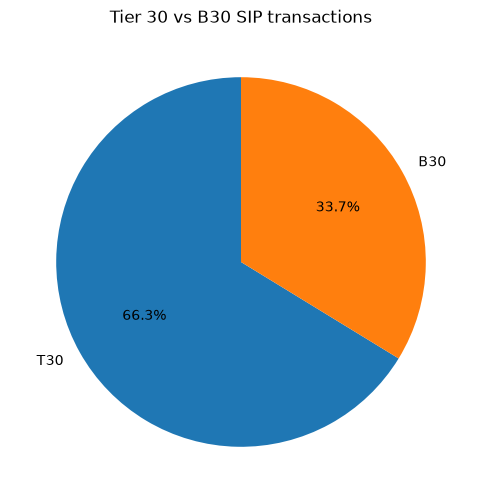

In [83]:
plt.figure(figsize = (6,6))

plt.pie(
    tier, labels = tier.index, autopct = "%1.1f%%",
    startangle=90
)

plt.title("Tier 30 vs B30 SIP transactions")

plt.show()

## Geographic Distribution

The states with the highest total SIP investments contribute the largest share of mutual fund inflows, indicating stronger investor participation in these regions.

The horizontal bar chart clearly highlights regional differences in SIP investments across states.

The Tier 30 vs B30 chart shows the proportion of investments coming from metropolitan (Tier 30) and non-metropolitan (B30) locations.

A higher share of Tier 30 investments suggests stronger participation from major urban centers, while a significant B30 share indicates growing adoption of mutual funds in smaller cities.

## Task 7 
Folio count growth: Line chart Jan
2022 to Dec 2025 showing growth
from 13.26 to 26.12 crore.

In [88]:
growth = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [89]:
growth.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [90]:
growth.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [91]:
growth.dtypes

month                      str
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_folios_crore    float64
others_folios_crore    float64
dtype: object

In [92]:
growth["month"] = pd.to_datetime(growth["month"])

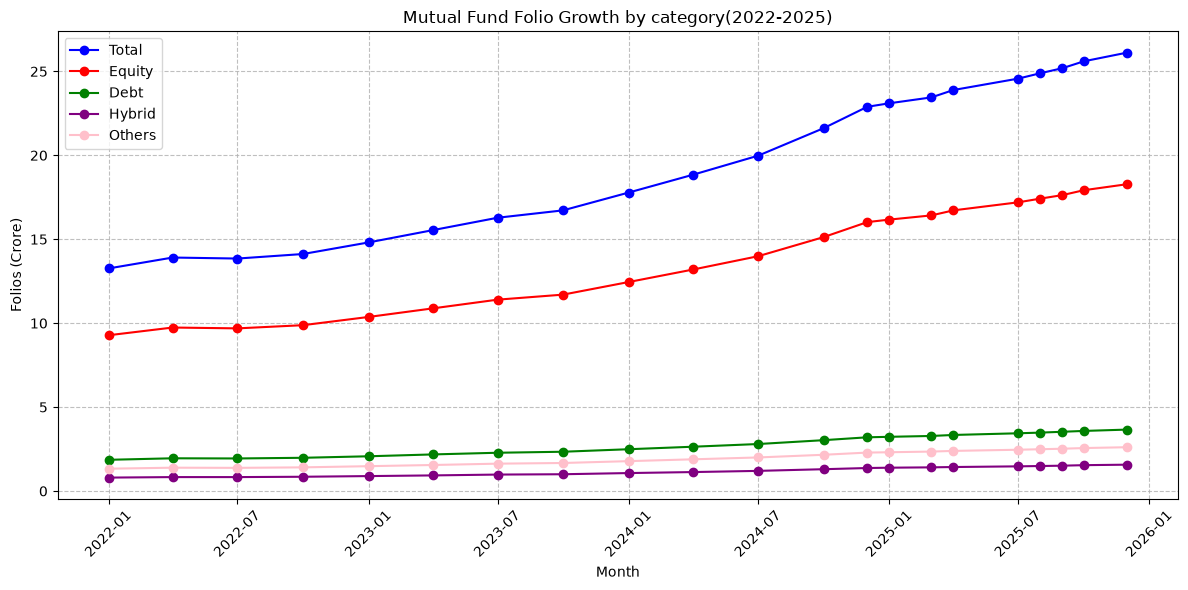

In [104]:
plt.figure(figsize = (12,6))

plt.plot(
    growth["month"], growth["total_folios_crore"], marker = "o", color = "blue", label = "Total")
plt.plot(
    growth["month"], growth["equity_folios_crore"], marker = "o", color = "red", label = "Equity")
plt.plot(
    growth["month"], growth["debt_folios_crore"], marker = "o", color = "green", label = "Debt")
plt.plot(
    growth["month"], growth["hybrid_folios_crore"], marker = "o", color = "purple", label = "Hybrid")
plt.plot(
    growth["month"], growth["others_folios_crore"], marker = "o", color = "pink", label = "Others")

plt.title("Mutual Fund Folio Growth by category(2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.8)

plt.legend()
plt.tight_layout()

plt.show()

## Findings
The mutual fund industry witnessed significant expansion between 2022 and 2025, with equity funds driving most of the increase in investor accounts while other categories also showed healthy and consistent growth.

## Task 8 
Correlation matrix: Compute pairwise
correlation of NAV returns across 10
selected funds.

In [135]:
funds = pd.read_csv("../data/processed/clean_nav.csv")

In [136]:
funds.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [137]:
funds["date"] = pd.to_datetime(funds["date"])

funds = funds.sort_values(["amfi_code", "date"])

In [138]:
top_10 = funds["amfi_code"].unique()[:10]

In [139]:
nav_10 = funds[funds["amfi_code"].isin(top_10)]

In [140]:
pivot = nav_10.pivot(
    index = "date", columns = "amfi_code", values = "nav")

In [ ]:
returns = pivot.pct_change().dropna() #remove rows where values are missing 
corr = returns.corr()   # correlation matrix

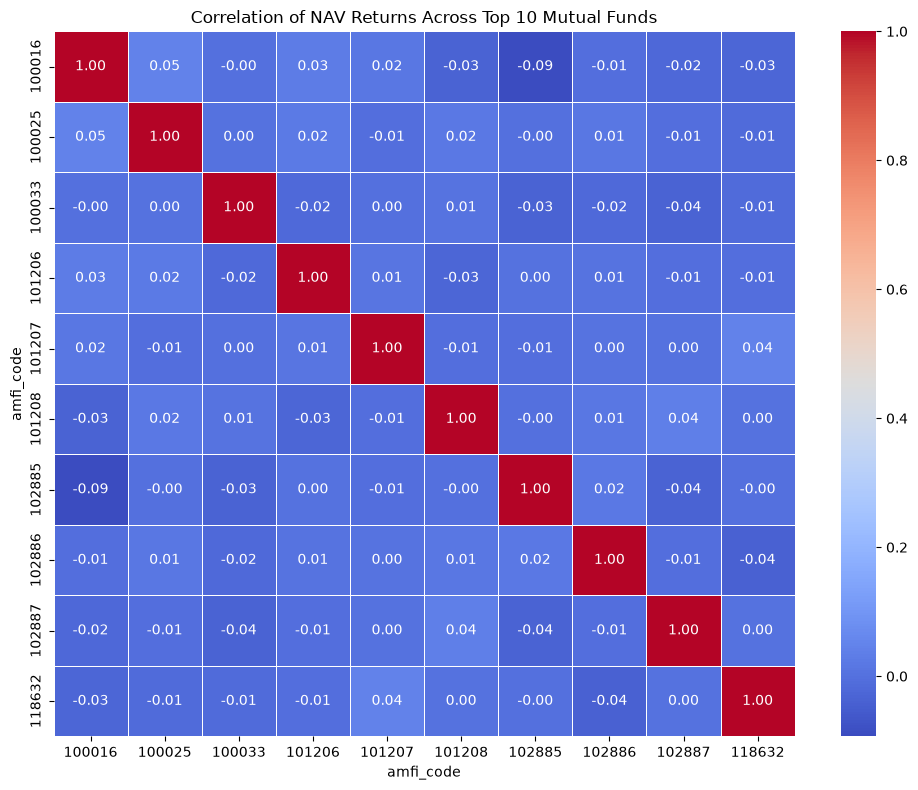

In [141]:
plt.figure(figsize = (10,8))

sns.heatmap(
    corr, annot = True, cmap = "coolwarm", fmt = ".2f", linewidth = 0.5)

plt.title("Correlation of NAV Returns Across Top 10 Mutual Funds")

plt.tight_layout()
plt.show()

## TASK 9 
Top holdings sector distribution:
Pie/donut chart of sector weights
across all equity fund portfolios.

In [146]:
df_weights = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [147]:
df_weights.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [148]:
df_weights.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [151]:
sector_data = df_weights.groupby("sector")["weight_pct"].sum().sort_values(ascending = False)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

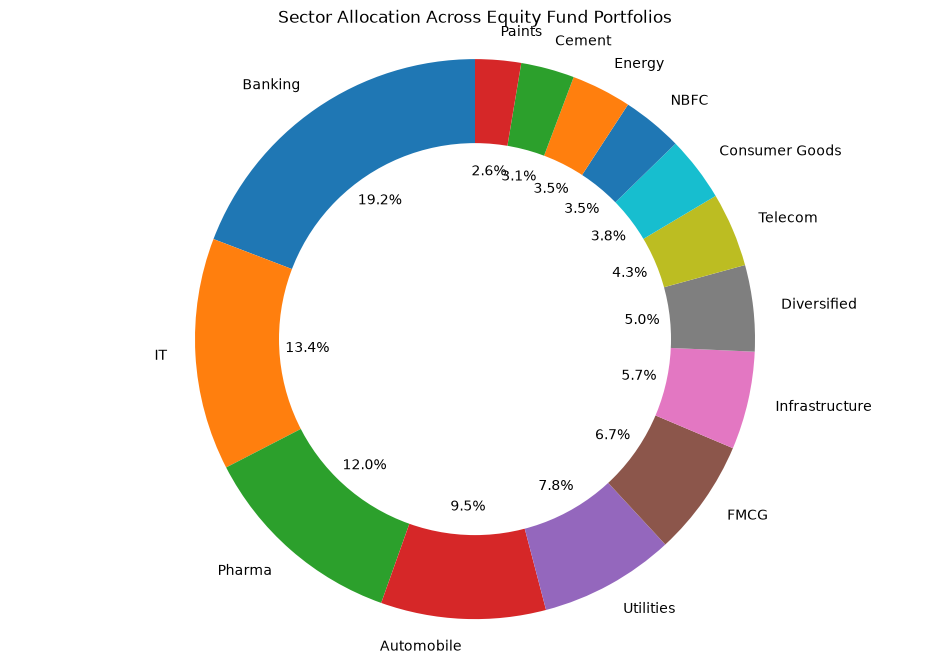

In [152]:
plt.figure(figsize=(12,8))

plt.pie(
    sector_data, labels = sector_data.index, autopct = "%1.1f%%", startangle = 90)

centre_circle = plt.Circle((0,0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Fund Portfolios")

plt.axis("equal")

plt.show()

## Findings
Banking has the highest allocation at 19.2%, making it the largest sector in the portfolio.
IT is the second-largest sector with 13.4%, indicating strong exposure to the technology industry.
Pharma (12.0%) and Automobile (9.5%) also have significant portfolio weights.
Utilities (7.8%) and FMCG (6.7%) contribute a moderate share, providing stability

## Task 10

# EDA Findings Summary

## 1. NAV Trend Analysis
- Most mutual funds showed a steady increase in NAV from 2022 to 2026.
- The overall market recovered well after the COVID period, followed by strong growth in 2023.
- Some funds experienced temporary corrections during 2024 before continuing their upward trend.

## 2. AUM Growth by Fund House
- SBI Mutual Fund has the highest Assets Under Management (AUM), exceeding ₹12.5 lakh crore.
- ICICI Prudential MF and HDFC Mutual Fund are the second and third largest fund houses.
- All major AMCs showed consistent AUM growth between 2022 and 2025.

## 3. SIP Inflow Trend
- Monthly SIP inflows increased steadily over the observed period.
- The highest SIP inflow was recorded in December 2025, indicating growing investor participation.

## 4. Category-wise Net Inflows
- Liquid Funds attracted the highest monthly net inflows.
- Most other fund categories maintained stable inflows with moderate monthly variation.

## 5. Investor Demographics
- Investors aged 26–35 represent the largest share of mutual fund investors.
- The 36–45 age group is the second largest contributor.
- The SIP investment distribution is relatively similar across different age groups.

## 6. Geographic Distribution
- Investment is concentrated in a few major states.
- The top contributing states account for the majority of total SIP investments.

## 7. Folio Growth
- Total folios increased steadily from 2022 to 2025.
- Equity folios experienced the fastest growth, reflecting increasing investor interest in equity mutual funds.

## 8. Correlation Analysis
- The correlation matrix was generated for the top 10 selected mutual funds based on daily NAV returns.
- Most selected funds showed weak correlations, suggesting relatively independent daily return movements in the available dataset.

## 9. Sector Allocation
- Banking is the largest sector with approximately 19.2% allocation.
- IT (13.4%) and Pharma (12.0%) are the next largest sectors.
- The portfolio is diversified across multiple industries including Automobile, Utilities, FMCG, Infrastructure, Telecom, and Energy.

## 10. Overall Conclusion
- The mutual fund industry demonstrated healthy growth in NAV, AUM, SIP inflows, and folio count during the analysis period.
- The portfolios are well diversified across sectors, while leading AMCs continue to dominate the market.
- Overall, the EDA indicates a positive growth trend in the Indian mutual fund industry from 2022 to 2026.